Make a plot of planetary radius as a function of equilibrium temperature and investigate whether there is a clear transition where inflation becomes significant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import csv

In [117]:
temps = []
radii = []
sm_as = []
names = []
st_lums = []
st_masss = []
st_mets = []
st_rads = []

# temp_uncs = {
#     "plus" : plus,

# }

with open("PSCompPars_2026(1485).csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # first non-metadata line
            header_line = line
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))
    # print(reader.fieldnames)

    for row in reader:
        if row["pl_eqt"] and row["pl_radj"] and row["st_lum"] and row["st_mass"] and row["st_met"] and row["pl_orbsmax"] and row["pl_name"] and row["st_rad"]:
            temps.append(float(row["pl_eqt"]))
            radii.append(float(row["pl_radj"]))
            sm_as.append(float(row["pl_orbsmax"]))
            st_lums.append(float(row["st_lum"]))
            st_masss.append(float(row["st_mass"]))
            st_mets.append(float(row["st_met"]))
            st_rads.append(float(row["st_rad"]))
            names.append(row["pl_name"])

In [99]:
J_temp = 122
J_rad = 1

In [132]:
def plot1(eqt, rad):
    plt.figure(figsize=(12,8))
    plt.scatter(eqt, rad, s=10)

    plt.scatter(J_temp, J_rad, color="red", s=10, label="Jupiter")

    x = np.linspace(min(eqt), max(eqt), 200)
    y = (1.1 * x ** 0.35) / 11
    plt.plot(x, y, linestyle="-", color="black", label="Inflation model")

    plt.xlabel("Equilibrium Temperature (°K)")
    plt.ylabel("Planetary Radius ($J_{rad}$)")
    plt.title("Figure 1")

    plt.legend()
    plt.show()


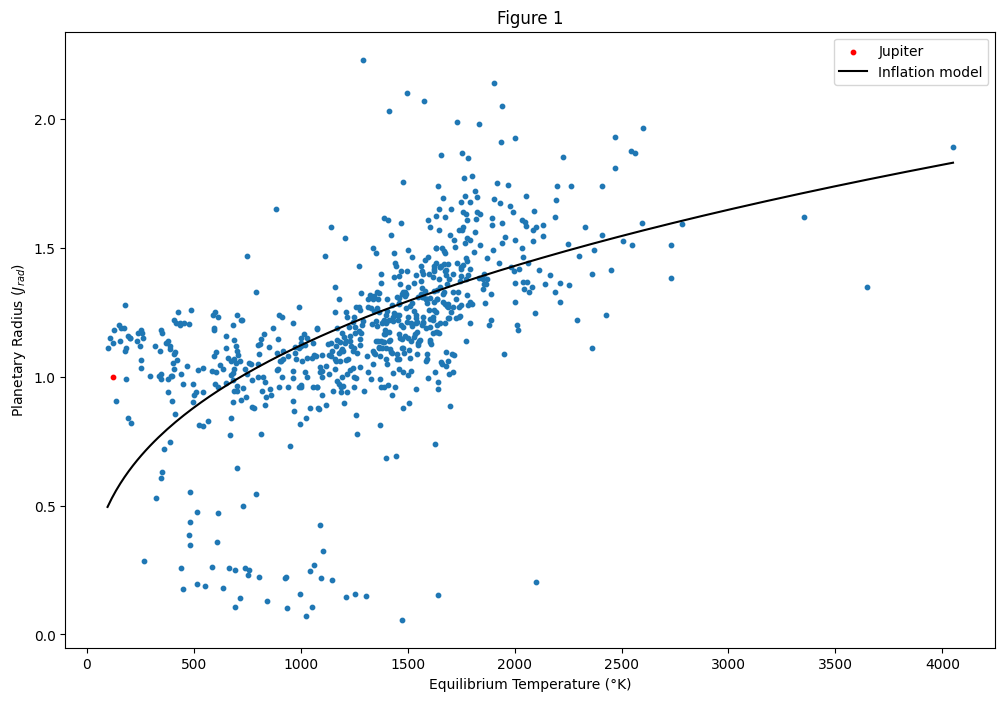

In [133]:
plot1(temps, radii)

How does the degree of inflation depend on incident flux?

In [102]:

# print(f"{len(temps)=}")
# print(f"{len(radii)=}")
# print(f"{len(names)=}")
# print(f"{len(st_lums)=}")
# print(f"{len(st_masss)=}")
# print(f"{len(st_mtlcts)=}")

# # degree_of_inflation = 100*(int($J_{rad}$) - 1) # Or just the radius
# # incident_flux = L/(4*Pi*r^2)

In [103]:
def plot2(flux, rad, xaxis, yaxis):
    plt.figure(figsize=(12,8))
    plt.scatter(flux, rad, s=10)

    plt.xlabel(xaxis)
    plt.ylabel(yaxis)
    plt.title("Figure 2")

    plt.show()


In [110]:
fluxes = []
distances = []
increase_percent = []

for pl_rad, st_rad, sm_a in zip(radii, st_rads, sm_as):
    dist = sm_a - st_rad - pl_rad
    distances.append(dist)

for dist, lum in zip(distances, st_lums):
    flux = lum / (4 * np.pi * dist**2)
    fluxes.append(flux)

    print(flux)

for temp, rad in zip(temps, radii):
    exp_rad = (1.1 * temp ** 0.35) / 11 # /11 to convert to Jupiter Radius
    increase = ((rad / exp_rad) - 1) * 100 # *100 to get a percentage
    increase_percent.append(increase)

    # print(rad)
    # print(temp)
    # print(exp_rad)
    # print(increase)
    # print()


0.004758272251704585
0.003582616804225797
0.003954186249690411
0.0008800799771253285
0.0018304332983557082
0.001624698754848748
-0.0026012308991330713
0.0051896074499319335
-0.0018907947436509135
0.001012193249432666
0.0039946365548594555
-0.003183938912004935
0.004928483576090064
0.002669539621352916
0.007883242619574663
0.0028542196221782016
0.002247509670973395
0.0004618696558435733
0.006367661693934441
0.00644201341998761
0.00300890061505445
0.0030918549728536585
0.005067496187954816
0.0005809849674872756
0.003979229724235942
-0.0068596343438877775
0.002809114438817303
-0.0018430493748021735
0.002439565852981978
0.004681520742021176
-0.0029979382043612873
-0.006296847784780893
0.0008173391193665707
0.0042951726467525195
0.0033854416714401672
0.005890561817629044
0.002450942858001504
0.0038157298250982782
0.006755179244098648
0.004128750816503096
0.000339211405815953
-0.004068165497316892
0.0048832606942739425
0.004295758858702384
0.005358167635420129
0.0030356370760591814
0.0037392

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\macau\AppData\Local\Temp\ipykernel_53540\780367070.py:2: SyntaxWarning: invalid escape sequence '\c'
  plot2(fluxes, increase_percent, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)")


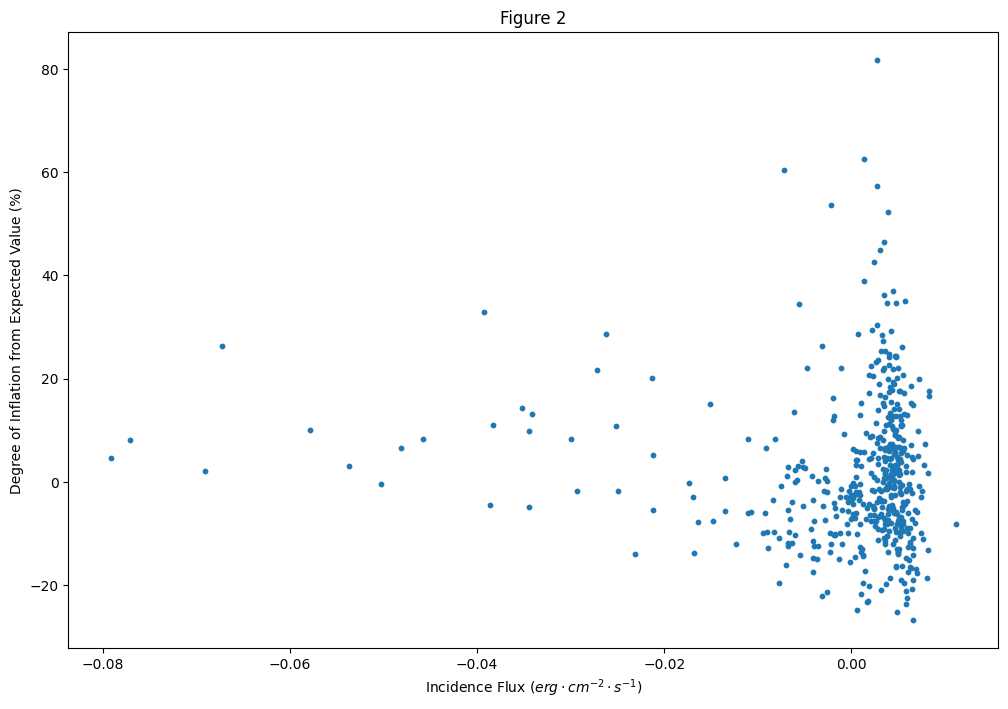

In [106]:
# plot2(fluxes, radii, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Planetary Radius ($J_{rad}$)")
plot2(fluxes, increase_percent, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)")